# Phase 6: LSTM Deep Learning Model

Objective:
To model sequential stock price patterns using Long Short-Term Memory (LSTM)
neural networks for trend prediction.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
df_model = pd.read_csv("../data/processed/reliance_processed.csv", index_col=0)

df_model.head()

,Close,Daily_Return,Rolling_Volatility,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_Ratio,Target
Price,,,,,,,,,,,,
2022-04-27,1264.182617,0.000973,0.017776,65.155013,31.005087,26.590278,4.414809,1208.040997,1140.257859,1096.517330,1.338175,-1
2022-04-28,1283.065796,0.014937,0.017956,67.746673,33.279303,27.928083,5.351221,1212.529694,1144.293364,1098.132168,1.674317,-1
2022-04-29,1269.597290,-0.010497,0.017841,64.085450,33.607435,29.063953,4.543482,1215.198328,1148.403940,1099.719364,1.181372,-1
2022-05-02,1265.138062,-0.003512,0.017473,62.873922,33.125806,29.876324,3.249482,1218.513086,1151.702773,1101.332950,0.621580,-1
2022-05-04,1225.643066,-0.031218,0.018997,53.268589,29.220361,29.745131,-0.524770,1219.373053,1154.257209,1102.719712,1.218453,-1


In [4]:
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

# Encode target for neural network
label_mapping = {-1: 0, 0: 1, 1: 2}
y_encoded = y.map(label_mapping)

In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
sequence_length = 20

X_sequences = []
y_sequences = []

for i in range(sequence_length, len(X_scaled)):
    X_sequences.append(X_scaled[i-sequence_length:i])
    y_sequences.append(y_encoded.iloc[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

X_sequences.shape

(928, 20, 11)

In [7]:
split_index = int(len(X_sequences) * 0.8)

X_train = X_sequences[:split_index]
X_test = X_sequences[split_index:]

y_train = y_sequences[:split_index]
y_test = y_sequences[split_index:]

In [8]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Dell\ai-stock-advisor\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,027 (129.01 KB)

 Trainable params: 33,027 (129.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.4919 - loss: 1.0443 - val_accuracy: 0.5968 - val_loss: 0.9545
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5189 - loss: 1.0376 - val_accuracy: 0.5968 - val_loss: 0.9820
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5189 - loss: 1.0279 - val_accuracy: 0.5968 - val_loss: 0.9536
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5189 - loss: 1.0258 - val_accuracy: 0.5968 - val_loss: 0.9708
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5189 - loss: 1.0272 - val_accuracy: 0.5968 - val_loss: 0.9677
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5189 - loss: 1.0274 - val_accuracy: 0.5968 - val_loss: 0.9522
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5189 - loss: 1.0267 - val_accuracy: 0.5968 - val_loss: 0.9560
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5189 - loss: 1.0184 - val_accuracy: 0.5968 - 

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("LSTM Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5968 - loss: 0.9654
LSTM Test Accuracy: 0.5967742204666138


# Why LSTM?

LSTM captures:

Temporal dependencies

Sequential momentum

Pattern memory

Unlike tree models, it understands time structure directly.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [12]:
df = pd.read_csv("../data/raw/RELIANCE.NS.csv", index_col=0)
df.index = pd.to_datetime(df.index, errors="coerce")

# Keep only Close
df = df[["Close"]]

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9792\2568859767.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


,Close
Price,
NaT,RELIANCE.NS
NaT,NaN
2021-03-02,954.9262084960938
2021-03-03,998.5009765625
2021-03-04,986.5984497070312


In [14]:
df = pd.read_csv("../data/raw/RELIANCE.NS.csv")

# Remove metadata rows
df = df[df.iloc[:,0] != "Ticker"]

# Rename first column to Date
df.rename(columns={df.columns[0]: "Date"}, inplace=True)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Date"])

# Set index
df.set_index("Date", inplace=True)

# Keep only Close
df = df[["Close"]]

# Convert Close to numeric
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

# Drop NaNs
df = df.dropna()

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9792\3820969599.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Close
Date,
2021-03-02,954.926208
2021-03-03,998.500977
2021-03-04,986.598450
2021-03-05,987.890686
2021-03-08,993.513306


In [15]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [16]:
sequence_length = 20

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

X.shape

(1217, 20, 1)

In [17]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [18]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # Single output for price

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

c:\Users\Dell\ai-stock-advisor\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0352 - val_loss: 0.0033
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0066 - val_loss: 0.0045
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0059 - val_loss: 0.0035
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0049 - val_loss: 0.0032
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0049 - val_loss: 0.0035
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0044 - val_loss: 0.0053
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0043 - val_loss: 0.0072
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038 - val_loss: 0.0030
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.

In [20]:
predictions = model.predict(X_test)

# Convert back to original price scale
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step


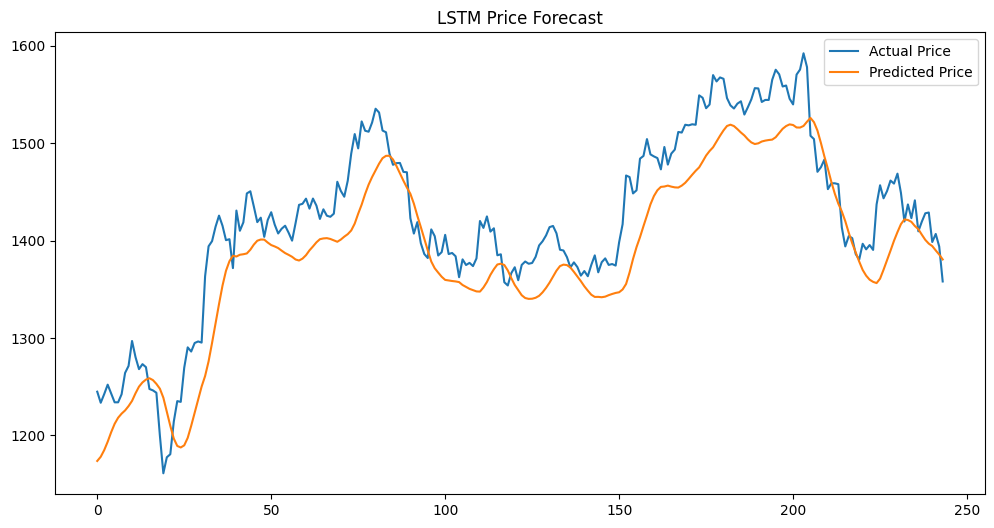

In [21]:
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label="Actual Price")
plt.plot(predictions_rescaled, label="Predicted Price")
plt.title("LSTM Price Forecast")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))

print("LSTM RMSE:", rmse)

LSTM RMSE: 45.64096540568897


# What This Model Now Does

Instead of predicting:

Up / Down / Stable

It predicts:

Exact next-day closing price

This is more continuous and realistic.